# DCGAN con EfficientNet como Discriminador (FashionMNIST)

**Objetivo:** adaptar el cuadernillo de GAN para implementar una **DCGAN** usando como **discriminador** una CNN **preentrenada EfficientNet** (transfer learning). El dataset principal es **FashionMNIST**; si diera problemas, cambiar a **MNIST** o **KMNIST**.

**Estrategia:**  
- Generador: arquitectura DCGAN (ConvTranspose2d) para producir imagenes 64x64.  
- Discriminador: EfficientNet-B0 preentrenada en ImageNet como extractor de caracteristicas; se reemplaza la cabeza para binario real/falso.  
- Perdida: BCE (o BCEWithLogitsLoss).  
- Optimizadores: Adam (betas=(0.5, 0.999)).  
- Metrica de monitoreo: perdida de G y D; guardado de muestras por epoca.

> Nota: EfficientNet espera entradas 224x224 y 3 canales. Para acelerar, usaremos **64x64** y **3 canales** replicando el canal de grises con `transforms.Grayscale(3)`. Tambien se puede reescalar a 128 o 224 si se desea (con mas costo de entrenamiento).


## 1. Preparacion e imports

In [10]:
import os, math
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils, models
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
outDir = Path("outputs_dcgan_efficientnet"); outDir.mkdir(parents=True, exist_ok=True)

seed = 42
torch.manual_seed(seed)
if device.type == "cuda":
    torch.cuda.manual_seed_all(seed)
print("device:", device)


device: cuda


## 2. Hiperparametros

In [11]:
imageSize = 64
batchSize = 128
latentDim = 128
gChannels = 128
numEpochs = 5   # reducido para ver graficas rapido; puedes subirlo
lrG = 2e-4
lrD = 2e-4
beta1 = 0.5
beta2 = 0.999
numWorkers = 2
sampleGrid = 64
saveEvery = 1
datasetName = "FashionMNIST"  # alternativas: "MNIST", "KMNIST"
freezeBackbone = True         # puedes poner False para fine-tuning completo


## 3. Dataset y DataLoader (FashionMNIST; fallback a MNIST/KMNIST)

In [3]:

def get_dataset(name, image_size):
    tfm = transforms.Compose([
        transforms.Resize(image_size),
        transforms.Grayscale(3),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])
    root = "./data"
    name = name.lower()
    if name == "fashionmnist":
        return datasets.FashionMNIST(root=root, train=True, download=True, transform=tfm)
    if name == "mnist":
        return datasets.MNIST(root=root, train=True, download=True, transform=tfm)
    if name == "kmnist":
        return datasets.KMNIST(root=root, train=True, download=True, transform=tfm)
    raise ValueError("dataset no soportado")

try:
    ds = get_dataset(datasetName, imageSize)
except Exception as e:
    print("No se pudo usar", datasetName, "-> fallback a MNIST. Error:", e)
    datasetName = "MNIST"
    ds = get_dataset(datasetName, imageSize)

dl = DataLoader(ds, batch_size=batchSize, shuffle=True, num_workers=numWorkers, pin_memory=True)


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 206kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.84MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.9MB/s]


## 4. Modelo: Generador (DCGAN)

In [12]:
def get_dataset(name, image_size):
    tfm = transforms.Compose([
        transforms.Resize(image_size),
        transforms.Grayscale(3),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])
    root = "./data"
    name = name.lower()
    if name == "fashionmnist":
        return datasets.FashionMNIST(root=root, train=True, download=True, transform=tfm)
    if name == "mnist":
        return datasets.MNIST(root=root, train=True, download=True, transform=tfm)
    if name == "kmnist":
        return datasets.KMNIST(root=root, train=True, download=True, transform=tfm)
    raise ValueError("dataset no soportado")

try:
    ds = get_dataset(datasetName, imageSize)
except Exception as e:
    print("No se pudo usar", datasetName, "-> fallback a MNIST. Error:", e)
    datasetName = "MNIST"
    ds = get_dataset(datasetName, imageSize)

dl = DataLoader(ds, batch_size=batchSize, shuffle=True, num_workers=numWorkers, pin_memory=True)
len(ds)


60000

In [13]:
class Generator(nn.Module):
    def __init__(self, z_dim=128, base=128, out_ch=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, base*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base*8), nn.ReLU(True),
            nn.ConvTranspose2d(base*8, base*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*4), nn.ReLU(True),
            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2), nn.ReLU(True),
            nn.ConvTranspose2d(base*2, base, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base), nn.ReLU(True),
            nn.ConvTranspose2d(base, out_ch, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z): return self.net(z)

G = Generator(latentDim, gChannels, 3).to(device)


In [14]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def make_discriminator(freeze_backbone=True):
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_features, 1)
    if freeze_backbone:
        for p in m.features.parameters():
            p.requires_grad = False
    return m

D = make_discriminator(freeze_backbone=freezeBackbone).to(device)


In [15]:
def weights_init_dcgan(m):
    name = m.__class__.__name__
    if "Conv" in name:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    if "BatchNorm" in name:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G.apply(weights_init_dcgan)


Generator(
  (net): Sequential(
    (0): ConvTranspose2d(128, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
 

In [16]:
criterion = nn.BCEWithLogitsLoss()
optG = optim.Adam(G.parameters(), lr=lrG, betas=(beta1, beta2))
optD = optim.Adam(filter(lambda p: p.requires_grad, D.parameters()), lr=lrD, betas=(beta1, beta2))

fixedZ = torch.randn(sampleGrid, latentDim, 1, 1, device=device)

def plot_grid(tensor, nrow=8, title=None):
    grid = utils.make_grid(tensor, nrow=nrow, normalize=True, value_range=(-1,1))
    plt.figure(figsize=(6,6))
    plt.axis("off")
    if title: plt.title(title)
    plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())
    plt.show()


## 5. Modelo: Discriminador con EfficientNet preentrenada

Usamos EfficientNet-B0 con pesos de ImageNet como extractor. Se reemplaza la cabeza por una capa lineal a 1 logit. Se puede congelar parcialmente el backbone.


In [5]:

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def make_discriminator(freeze_backbone=True):
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_features, 1)
    if freeze_backbone:
        for p in m.features.parameters():
            p.requires_grad = False
    return m

D = make_discriminator(freeze_backbone=True).to(device)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 158MB/s]


epoch 001 | lossD 1.3705 | lossG 0.7186


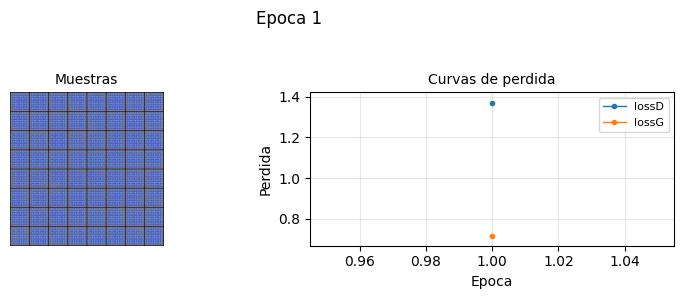

epoch 002 | lossD 1.3703 | lossG 0.7199


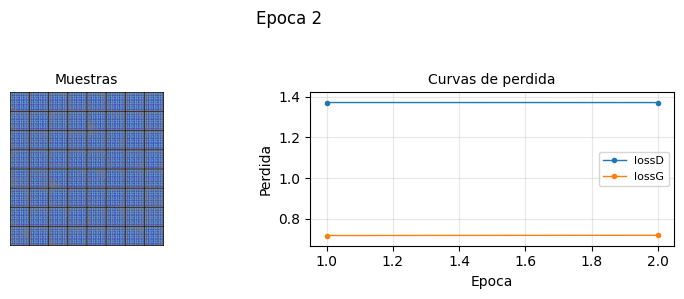

epoch 003 | lossD 1.3719 | lossG 0.7196


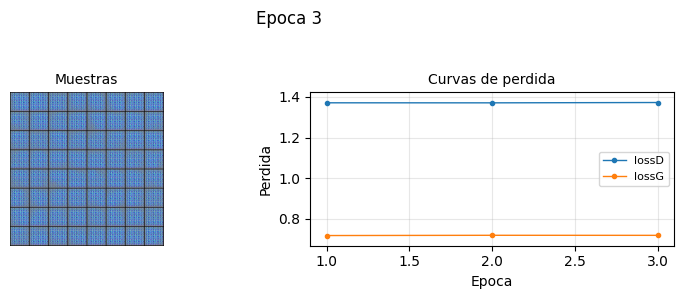

epoch 004 | lossD 1.3729 | lossG 0.7170


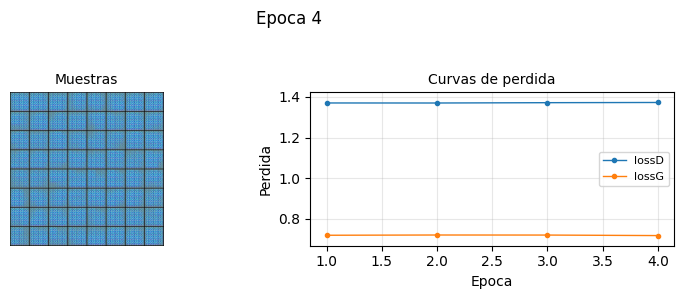

epoch 005 | lossD 1.3733 | lossG 0.7161


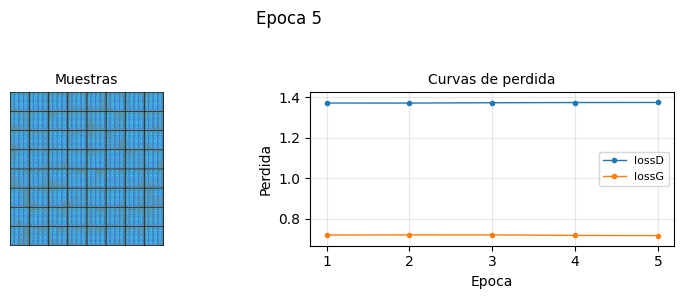


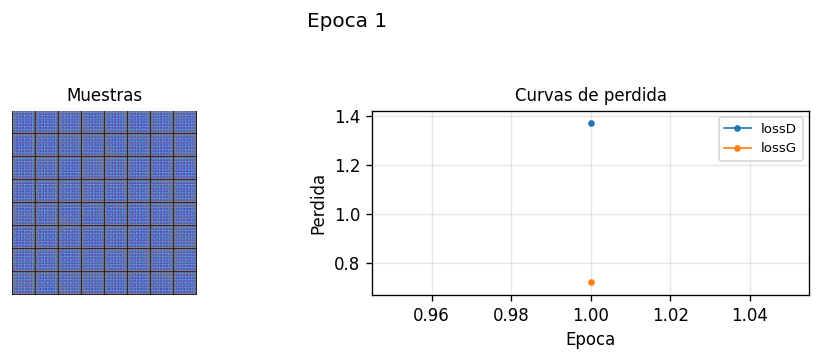
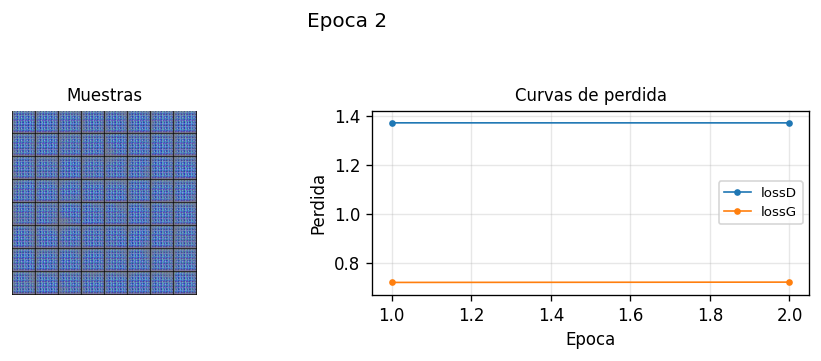
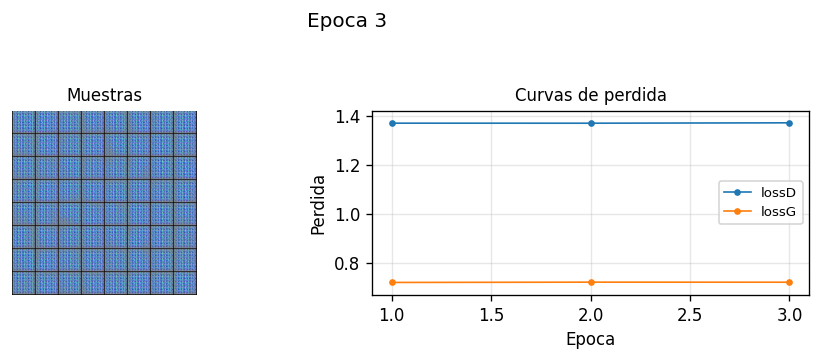
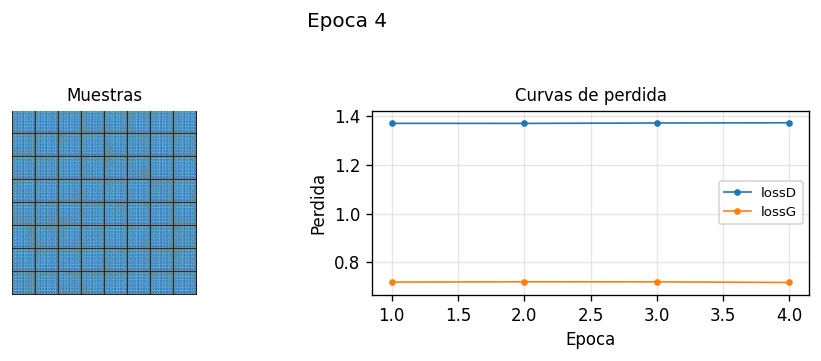
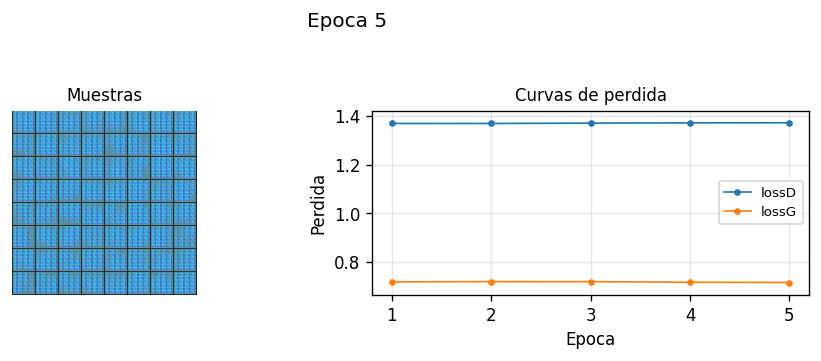

In [20]:
from IPython.display import display, HTML
import base64, io

historyD, historyG = [], []

def make_grid_img(tensor, nrow):
    grid = utils.make_grid(tensor, nrow=nrow, normalize=True, value_range=(-1,1))
    return grid.permute(1,2,0).detach().cpu().numpy()

def render_panel(epoch, samples, histD, histG, nrow):
    # Figura "pequena": muestra + curva
    fig = plt.figure(figsize=(8, 3))  # pequeno
    fig.suptitle(f"Epoca {epoch}", fontsize=12)

    # --- Subplot 1: muestras ---
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.set_title("Muestras", fontsize=10)
    ax1.axis("off")
    img = make_grid_img(samples, nrow=nrow)
    ax1.imshow(img)

    # --- Subplot 2: curvas ---
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.set_title("Curvas de perdida", fontsize=10)
    xs = list(range(1, len(histD)+1))
    ax2.plot(xs, histD, marker="o", linewidth=1, markersize=3, label="lossD")
    ax2.plot(xs, histG, marker="o", linewidth=1, markersize=3, label="lossG")
    ax2.set_xlabel("Epoca"); ax2.set_ylabel("Perdida")
    ax2.grid(True, alpha=0.3); ax2.legend(fontsize=8, loc="best")
    # Limites suaves
    ymin = min(histD + histG) - 0.05
    ymax = max(histD + histG) + 0.05
    ax2.set_ylim(max(0.0, ymin), ymax)

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    # Guardar panel
    panel_path = outDir / f"panel_epoch_{epoch:03d}.png"
    fig.savefig(panel_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return panel_path

def train_dcgan():
    panel_paths = []
    for epoch in range(1, numEpochs+1):
        G.train(); D.train()
        sumLossG = 0.0; sumLossD = 0.0; n = 0
        for x, _ in dl:
            x = x.to(device)
            b = x.size(0)
            realLab = torch.ones(b, 1, device=device)
            fakeLab = torch.zeros(b, 1, device=device)

            # --- Update D ---
            optD.zero_grad()
            realLogits = D(x)
            lossDReal = criterion(realLogits, realLab)
            z = torch.randn(b, latentDim, 1, 1, device=device)
            fake = G(z).detach()
            fakeLogits = D(fake)
            lossDFake = criterion(fakeLogits, fakeLab)
            lossD = lossDReal + lossDFake
            lossD.backward()
            optD.step()

            # --- Update G ---
            optG.zero_grad()
            z = torch.randn(b, latentDim, 1, 1, device=device)
            gen = G(z)
            genLogits = D(gen)
            lossG = criterion(genLogits, realLab)
            lossG.backward()
            optG.step()

            sumLossD += lossD.item() * b
            sumLossG += lossG.item() * b
            n += b

        avgLossD = sumLossD / n
        avgLossG = sumLossG / n
        historyD.append(avgLossD); historyG.append(avgLossG)
        print(f"epoch {epoch:03d} | lossD {avgLossD:.4f} | lossG {avgLossG:.4f}")

        # Muestras fijas + guardado (para consistencia visual)
        G.eval()
        with torch.no_grad():
            samples = G(fixedZ).cpu()
        utils.save_image(
            samples, str(outDir / f"samples_epoch_{epoch:03d}.png"),
            nrow=int(math.sqrt(sampleGrid)), normalize=True, value_range=(-1,1)
        )

        # Panel lado-a-lado pequeno y guardado
        panel_paths.append(
            render_panel(epoch, samples, historyD, historyG, nrow=int(math.sqrt(sampleGrid)))
        )

        # Checkpoint
        torch.save({"G": G.state_dict(), "D": D.state_dict(),
                    "hD": historyD, "hG": historyG},
                   outDir / f"ckpt_epoch_{epoch:03d}.pt")

    # --- Galeria (HTML) de todos los paneles ---
    thumbs = []
    for p in panel_paths:
        with open(p, "rb") as f:
            b64 = base64.b64encode(f.read()).decode("ascii")
        thumbs.append(f'<div class="item"><img src="data:image/png;base64,{b64}" /><div class="cap">{p.name}</div></div>')

    html = f"""
    <style>
    .grid {{ display:grid; grid-template-columns: repeat(auto-fill, minmax(280px,1fr)); gap:12px; }}
    .item {{ border:1px solid #ddd; border-radius:6px; padding:6px; background:#fafafa; }}
    .item img {{ width:100%; height:auto; display:block; }}
    .cap {{ font:12px/1.3 system-ui, Arial; color:#444; margin-top:4px; text-align:center; }}
    </style>
    <h3>Galeria de paneles (muestra + curva)</h3>
    <div class="grid">{''.join(thumbs)}</div>
    """
    display(HTML(html))

# Entrenar
train_dcgan()


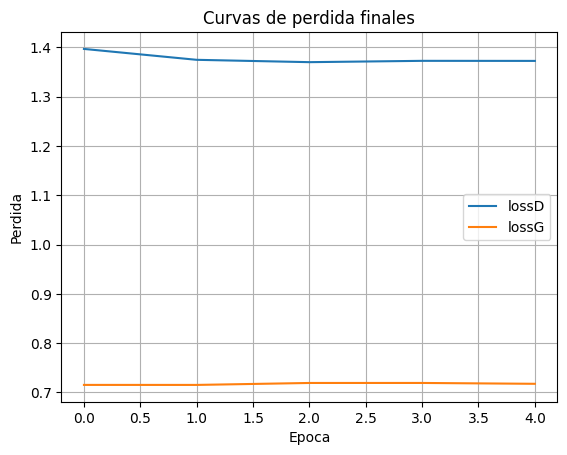

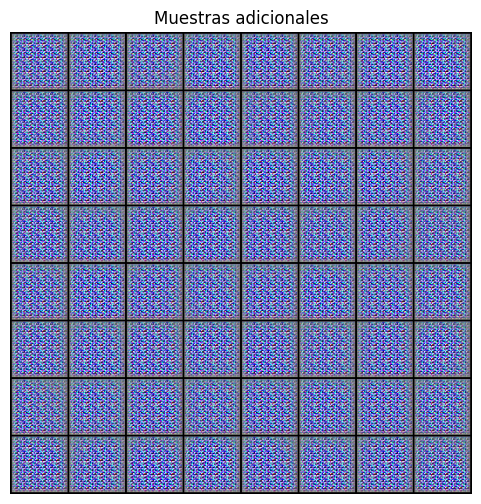

In [18]:
# Curvas finales
plt.figure()
plt.plot(historyD, label="lossD")
plt.plot(historyG, label="lossG")
plt.xlabel("Epoca"); plt.ylabel("Perdida"); plt.legend(); plt.grid(True)
plt.title("Curvas de perdida finales")
plt.savefig(outDir / "loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()

# Grid adicional de muestras con ruido nuevo
with torch.no_grad():
    z = torch.randn(64, latentDim, 1, 1, device=device)
    imgs = G(z).cpu()
plot_grid(imgs, nrow=8, title="Muestras adicionales")
utils.save_image(imgs, str(outDir / "samples_final.png"),
                 nrow=8, normalize=True, value_range=(-1,1))
